In [4]:
!pip uninstall numpy scipy
!pip install numpy==1.26.4
!pip install --no-cache-dir scipy


^C


In [ ]:
# Load model directly
from datasets import load_dataset
import torch
import numpy as np

cache_directory = "E:/huggingface_cache"

ds = load_dataset("OpenLLM-France/Claire-Dialogue-French-0.1",token="")

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

In [ ]:
5457 -> 5461

In [2]:
text = ds["train"]["text"][0]
print(text)

[speaker001:] Alors est-ce que vous êtes née dans la région de Toulouse ?
[speaker002:] Non je suis pas née dans la région de Toulouse en fait je suis née au Portugal et donc mes parents ont immigré euh j'avais trois mois donc j'ai juste eu le temps de de naître et euh après ils sont allés dans la région euh en euh de Corrèze et puis ils sont venus à Toulouse j'avais deux trois ans.
[speaker001:] Hum hum et après donc vous avez toujours habité Toulouse en fait
[speaker002:] Oui oui oui !
[speaker001:] donc en fait pour vous vos vos racines enfin même si je suppose que le Portugal ça compte mais ce- ceci étant pour votre enfance et tout ça c'est Toulouse qui vous...
[speaker002:] Oui ! Oui oui c'est vrai que c'est Toulouse enfin vraiment qui est euh enfin qui est dans ma tête euh dans mon coeur euh il faut euh
[speaker001:] Oui c'est ça [XXX]
[speaker002:] enfin je c'est vrai je me sens euh bon vraiment toulousaine quoi ! Et euh bon après dans dans le cadre de mes activités professionne

In [3]:
import re

In [5]:
text = re.sub(r"\[.*?\]", "", text).strip().lower()

In [6]:
print(text)

alors est-ce que vous êtes née dans la région de toulouse ?
 non je suis pas née dans la région de toulouse en fait je suis née au portugal et donc mes parents ont immigré euh j'avais trois mois donc j'ai juste eu le temps de de naître et euh après ils sont allés dans la région euh en euh de corrèze et puis ils sont venus à toulouse j'avais deux trois ans.
 hum hum et après donc vous avez toujours habité toulouse en fait
 oui oui oui !
 donc en fait pour vous vos vos racines enfin même si je suppose que le portugal ça compte mais ce- ceci étant pour votre enfance et tout ça c'est toulouse qui vous...
 oui ! oui oui c'est vrai que c'est toulouse enfin vraiment qui est euh enfin qui est dans ma tête euh dans mon coeur euh il faut euh
 oui c'est ça 
 enfin je c'est vrai je me sens euh bon vraiment toulousaine quoi ! et euh bon après dans dans le cadre de mes activités professionnelles j'ai du partir euh à lille où je suis restée quatre ans et c'est vrai que ça a été un peu difficile de qu

In [7]:
text = re.sub(r"(?<!\w)[a-zA-Zà-üÀ-Ü]+-(?![a-zA-Zà-üÀ-Ü])","",text)

In [8]:
print(text)

alors est-ce que vous êtes née dans la région de toulouse ?
 non je suis pas née dans la région de toulouse en fait je suis née au portugal et donc mes parents ont immigré euh j'avais trois mois donc j'ai juste eu le temps de de naître et euh après ils sont allés dans la région euh en euh de corrèze et puis ils sont venus à toulouse j'avais deux trois ans.
 hum hum et après donc vous avez toujours habité toulouse en fait
 oui oui oui !
 donc en fait pour vous vos vos racines enfin même si je suppose que le portugal ça compte mais  ceci étant pour votre enfance et tout ça c'est toulouse qui vous...
 oui ! oui oui c'est vrai que c'est toulouse enfin vraiment qui est euh enfin qui est dans ma tête euh dans mon coeur euh il faut euh
 oui c'est ça 
 enfin je c'est vrai je me sens euh bon vraiment toulousaine quoi ! et euh bon après dans dans le cadre de mes activités professionnelles j'ai du partir euh à lille où je suis restée quatre ans et c'est vrai que ça a été un peu difficile de quitt

In [9]:
text = re.sub(r"\s+", " ", text).strip()

In [10]:
print(text)

alors est-ce que vous êtes née dans la région de toulouse ? non je suis pas née dans la région de toulouse en fait je suis née au portugal et donc mes parents ont immigré euh j'avais trois mois donc j'ai juste eu le temps de de naître et euh après ils sont allés dans la région euh en euh de corrèze et puis ils sont venus à toulouse j'avais deux trois ans. hum hum et après donc vous avez toujours habité toulouse en fait oui oui oui ! donc en fait pour vous vos vos racines enfin même si je suppose que le portugal ça compte mais ceci étant pour votre enfance et tout ça c'est toulouse qui vous... oui ! oui oui c'est vrai que c'est toulouse enfin vraiment qui est euh enfin qui est dans ma tête euh dans mon coeur euh il faut euh oui c'est ça enfin je c'est vrai je me sens euh bon vraiment toulousaine quoi ! et euh bon après dans dans le cadre de mes activités professionnelles j'ai du partir euh à lille où je suis restée quatre ans et c'est vrai que ça a été un peu difficile de quitter euh to

In [ ]:
onomatopeia = ["euh"]

### Train

In [ ]:
FR/ACSYNT/train.txt,fr,False,False,False,True,144 ✅
---------------------------------------------------------------------------------------------------------
FR/AssembleeNationale_13/train.txt,fr,True,False,False,False,1248 ✅
FR/AssembleeNationale_14/train.txt,fr,True,False,False,False,1320 ✅
FR/AssembleeNationale_15/train.txt,fr,True,False,False,False,1539 ✅
FR/AssembleeNationale_16/train.txt,fr,True,False,False,False,381 ✅
---------------------------------------------------------------------------------------------------------
FR/CFPP/train.txt,fr,False,False,False,True,42 -> Interviews of people in Paris in 2000 ✅
---------------------------------------------------------------------------------------------------------
FR/CID/train.txt,fr,False,False,False,True,8 -> Dialogues between two friends ✅
FR/CLAPI/train.txt,fr,False,False,False,True,14 -> Diverse conversation ✅
---------------------------------------------------------------------------------------------------------
FR/ESLO_assistance/train.txt,fr,False,False,False,True,139 -> In-person assistance and call-centers ✅
---------------------------------------------------------------------------------------------------------
FR/ESLO_conf/train.txt,fr,False,False,False,True,4 -> Conferences ✅
---------------------------------------------------------------------------------------------------------
FR/ESLO_discourse/train.txt,fr,False,False,False,True,9 -> Conference presentations ✅
---------------------------------------------------------------------------------------------------------
FR/ESLO_free/train.txt,fr,False,False,False,True,95 -> 	Diverse conversation ✅
---------------------------------------------------------------------------------------------------------
FR/ESLO_interview/train.txt,fr,False,False,False,True,392 -> Guided conversations ✅
---------------------------------------------------------------------------------------------------------
FR/FREDSum/train.txt,fr,True,False,False,True,115 -> French political debates ✅
---------------------------------------------------------------------------------------------------------
FR/LINAGORA_discourse/train.txt,fr,False,False,False,True,3 -> Technical presentations (AI topics) with Q/A ✅
---------------------------------------------------------------------------------------------------------
FR/LINAGORA_free/train.txt,fr,False,False,False,True,4 -> Diverse conversation ✅
---------------------------------------------------------------------------------------------------------
FR/LINAGORA_meetings/train.txt,fr,False,False,False,True,6 -> Meetings on speech recognition ✅
---------------------------------------------------------------------------------------------------------
FR/OFROM/train.txt,fr,False,False,False,True,137 --> Switzerland ✅
FR/ORFEO_cfpb/train.txt,fr,False,False,False,True,12 --> Belgium ✅
---------------------------------------------------------------------------------------------------------
FR/ORFEO_coralrom/train.txt,fr,False,False,False,True,152 -> Diverse conversation ✅
FR/ORFEO_crfp/train.txt,fr,False,False,False,True,124 -> Diverse conversations ✅
---------------------------------------------------------------------------------------------------------
FR/ORFEO_fleuron/train.txt,fr,False,False,False,True,49 -> Interactions created to teach foreign students about university life ✅
---------------------------------------------------------------------------------------------------------
FR/ORFEO_reunions-de-travail/train.txt,fr,False,False,False,True,27 -> Real meetings ✅
---------------------------------------------------------------------------------------------------------
FR/ORFEO_valibel_discourse/train.txt,fr,False,False,False,True,5 -> Formal university addresses ✅
---------------------------------------------------------------------------------------------------------
FR/ORFEO_valibel_interview/train.txt,fr,False,False,False,True,67 --> Belgium ✅
---------------------------------------------------------------------------------------------------------
FR/OTG/train.txt,fr,False,False,False,True,314 -> Dialogues in a tourism office ✅
---------------------------------------------------------------------------------------------------------
FR/PFC_free/train.txt,fr,False,False,False,True,146 -> Diverse conversation ✅
---------------------------------------------------------------------------------------------------------
FR/PFC_guided/train.txt,fr,False,False,False,True,173 -> Guided interviews ✅
---------------------------------------------------------------------------------------------------------
FR/ParisStories/train.txt,fr,False,False,False,True,41 -> Diverse conversations in Paris ✅
FR/Rhapsodie/train.txt,fr,False,False,False,True,32 -> Diverse conversations ✅
---------------------------------------------------------------------------------------------------------
FR/SUMM-RE/train.txt,fr,False,True,False,True,210 -> Meeting-style conversations (transcribed with Whisper large-v2 ASR) ✅
---------------------------------------------------------------------------------------------------------
FR/TCOF_adults/train.txt,fr,False,False,False,True,237 -> Guided conversations (between adults) ✅
---------------------------------------------------------------------------------------------------------
FR/TheatreClassique/train.txt,fr,True,False,True,False,25422 -> Classic stage plays ✅
FR/TheatreGratuit/train.txt,fr,True,False,True,False,4080 -> Stage plays ✅
---------------------------------------------------------------------------------------------------------
FR/UBS/train.txt,fr,False,False,False,True,40 -> 	University telephone answering service ✅

In [ ]:
0 -> 143 : Interview --- Casual
144 -> 4631 : Parliamentary proceedings --- Polite
4632 -> 4673 : Interview --- Casual
4674 -> 4695 : Free Conversations --- Casual
4696 -> 4834 : Assistance --- Polite
4835 -> 4838 : Debates
4839 -> 4847 : Presentation, Formal Address
4848 -> 4942 : Free Conversation --- Casual
4943 -> 5334 : Interview --- Casual
5335 -> 5449 : Debates
5450 -> 5452 : Presentation, Formal Address
5453 -> 5456 : Free Conversation --- Casual
5457 -> 5462 : Meetings --- Casual
5463 -> 5611 : Free Conversation not used
5612 -> 5887 : Free Conversation --- Casual
5888 -> 5936 : Assistance --- Polite
5937 -> 5963 : Meetings --- Casual
5964 -> 5968 : Presentation, Formal Address
5969 -> 6035 : Free Conversation not used
6036 -> 6349 : Assistance --- Polite
6350 -> 6495 : Free Conversation --- Casual
6496 -> 6668 : Interview --- Casual
6669 -> 6709 : Free Conversation --- Casual
6710 -> 6741 : Free Conversation --- Casual
6742 -> 6951 : Meetings --- Casual
6952 -> 7188 : Interview --- Casual
7189 -> 32610 : Classic theatre --- Litterature
32611 -> 36690 : Free theatre --- Litterature
36691 -> 36731 : Assistance --- Polite

In [ ]:
----------------------- CASUAL -----------------------------
0 -> 143 : Interview --- Casual
4632 -> 4673 : Interview --- Casual
4674 -> 4695 : Free Conversations --- Casual
4848 -> 4942 : Free Conversation --- Casual
4943 -> 5334 : Interview --- Casual
5453 -> 5456 : Free Conversation --- Casual
5457 -> 5462 : Meetings --- Casual
5612 -> 5887 : Free Conversation --- Casual
5937 -> 5963 : Meetings --- Casual
6350 -> 6495 : Free Conversation --- Casual
6496 -> 6668 : Interview --- Casual
6669 -> 6709 : Free Conversation --- Casual
6710 -> 6741 : Free Conversation --- Casual
6742 -> 6951 : Meetings --- Casual
6952 -> 7188 : Interview --- Casual
----------------------- POLITE -----------------------------
144 -> 4631 : Parliamentary proceedings --- Polite
4696 -> 4834 : Assistance --- Polite
36691 -> 36731 : Assistance --- Polite
5888 -> 5936 : Assistance --- Polite
6036 -> 6349 : Assistance --- Polite
------------------------ FORMAL ----------------------------
4839 -> 4847 : Presentation, Formal Address --- Formal
5450 -> 5452 : Presentation, Formal Address --- Formal
5964 -> 5968 : Presentation, Formal Address  --- Formal
---------------------- LITTERATURE -------------------------
7189 -> 32610 : Classic theatre --- Litterature
32611 -> 36690 : Free theatre --- Litterature
------------------------------------------------------------
4835 -> 4838 : Debates
5335 -> 5449 : Debates
5463 -> 5611 : Free Conversation not used
5969 -> 6035 : Free Conversation not used

In [4]:
casual = []
casual += ds["train"]["text"][0:144]
casual += ds["train"]["text"][4632:4674]
casual += ds["train"]["text"][4674:4696]
casual += ds["train"]["text"][4848:4943]
casual += ds["train"]["text"][4943:5335]
casual += ds["train"]["text"][5453:5457]
casual += ds["train"]["text"][5457:5463]
casual += ds["train"]["text"][5612:5888]
casual += ds["train"]["text"][5937:5964]
casual += ds["train"]["text"][6350:6496]
casual += ds["train"]["text"][6496:6669]
casual += ds["train"]["text"][6669:6710]
casual += ds["train"]["text"][6710:6742]
casual += ds["train"]["text"][6742:6952]
casual += ds["train"]["text"][6952:7189]

In [6]:
import string

def clean_text(text):
    text = re.sub(r"\[.*?\]", "", text).strip().lower()
    text = re.sub(r"(?<!\w)[a-zA-Zà-üÀ-Ü]+-(?![a-zA-Zà-üÀ-Ü])","",text)
    stop_words = ["euh","hum"]
    for word in stop_words:
        text = text.replace(word,"")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.translate(str.maketrans(string.punctuation.replace("'", ""), " " * len(string.punctuation.replace("'", ""))))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [7]:
casual = [clean_text(text) for text in casual]

NameError: name 'casual' is not defined

In [36]:
print(casual[0])

alors est ce que vous êtes née dans la région de toulouse non je suis pas née dans la région de toulouse en fait je suis née au portugal et donc mes parents ont immigré j'avais trois mois donc j'ai juste eu le temps de de naître et après ils sont allés dans la région en de corrèze et puis ils sont venus à toulouse j'avais deux trois ans et après donc vous avez toujours habité toulouse en fait oui oui oui donc en fait pour vous vos vos racines enfin même si je suppose que le portugal ça compte mais ceci étant pour votre enfance et tout ça c'est toulouse qui vous oui oui oui c'est vrai que c'est toulouse enfin vraiment qui est enfin qui est dans ma tête dans mon coeur il faut oui c'est ça enfin je c'est vrai je me sens bon vraiment toulousaine quoi et bon après dans dans le cadre de mes activités professionnelles j'ai du partir à lille où je suis restée quatre ans et c'est vrai que ça a été un peu difficile de quitter toulouse quoi pour vous en fait vos vos racines où si on vous parle de

In [7]:
import re

def segment_text_smart(text, max_length=30):
    breakpoints = ["et", "mais", "donc", "en fait", "c'est vrai", "quoi", "voilà", "bon", "hein"]
    words = text.split()
    segments = []
    segment = []
    
    for i, word in enumerate(words):
        segment.append(word)

        # Prioritize splitting at breakpoints within reasonable word limits
        if word in breakpoints and len(segment) >= max_length * 0.7:
            segments.append(" ".join(segment))
            segment = []
        
        # Ensure segment does not exceed max_length
        elif len(segment) >= max_length:
            segments.append(" ".join(segment))
            segment = []

    # Add any remaining words
    if segment:
        segments.append(" ".join(segment))
    
    return segments

In [8]:
casual_df = []
for sentence in casual:
    casual_df += segment_text_smart(sentence,max_length=30)

In [53]:
print(casual_df[0:10])

['alors est ce que vous êtes née dans la région de toulouse non je suis pas née dans la région de toulouse en fait je suis née au portugal et', "donc mes parents ont immigré j'avais trois mois donc j'ai juste eu le temps de de naître et après ils sont allés dans la région en de corrèze et", "puis ils sont venus à toulouse j'avais deux trois ans et après donc vous avez toujours habité toulouse en fait oui oui oui donc", 'en fait pour vous vos vos racines enfin même si je suppose que le portugal ça compte mais ceci étant pour votre enfance et', "tout ça c'est toulouse qui vous oui oui oui c'est vrai que c'est toulouse enfin vraiment qui est enfin qui est dans ma tête dans mon coeur il faut oui", "c'est ça enfin je c'est vrai je me sens bon vraiment toulousaine quoi et bon après dans dans le cadre de mes activités professionnelles j'ai du partir à lille où", "je suis restée quatre ans et c'est vrai que ça a été un peu difficile de quitter toulouse quoi pour vous en fait vos vos racines où

In [54]:
print(len(casual_df))

281964


In [ ]:
from datasets import Dataset
from transformers import GPT2Tokenizer

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(
    "gpt2", 
    token="")

In [10]:
tokenizer.pad_token = tokenizer.eos_token  # Set padding token

In [11]:
full_text = " ".join(casual_df)

In [12]:
tokenized_text = tokenizer(full_text, return_tensors="pt")["input_ids"][0]

# Define max length & stride for overlapping context
max_length = 1024  # GPT-2's max sequence length
stride = 200  # Allows overlap for better context retention

# Create chunks
chunks = []
for i in range(0, len(tokenized_text), max_length - stride):
    chunk = tokenized_text[i : i + max_length]
    chunks.append(chunk)

print(f"Total chunks: {len(chunks)}")

Token indices sequence length is longer than the specified maximum sequence length for this model (14865578 > 1024). Running this sequence through the model will result in indexing errors


Total chunks: 18041


In [13]:
from datasets import Dataset

# Convert list of chunks into a Dataset
dataset = Dataset.from_dict({"input_ids": [chunk.tolist() for chunk in chunks]})


In [14]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # GPT-2 is not a masked model
)


In [ ]:
from transformers import GPT2LMHeadModel, TrainingArguments, Trainer

# Load pre-trained GPT-2 model
model = GPT2LMHeadModel.from_pretrained("gpt2",token="")

# Define training arguments
training_args = TrainingArguments(
    output_dir="./gpt2-finetuned",
    overwrite_output_dir=True,
    per_device_train_batch_size=1,  # Adjust based on GPU RAM
    num_train_epochs=3,  # Number of training epochs
    save_steps=500,  # Save model every 500 steps
    save_total_limit=2,  # Keep only the last 2 checkpoints
    logging_dir="./logs",
    logging_steps=100,
    evaluation_strategy="no"  # Change to "steps" if you have a validation set
)


In [18]:
from transformers import TrainingArguments

# Update training arguments to disable reporting
training_args = TrainingArguments(
    output_dir="./gpt2-finetuned",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    logging_dir="./logs",
    logging_steps=500,
    save_steps=1000,
    report_to="none",
    # Disable WandB and other integrations
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    tokenizer=tokenizer,
    data_collator=data_collator
)

# Start fine-tuning
trainer.train()

# Save model and tokenizer
model.save_pretrained("./gpt2-finetuned")
tokenizer.save_pretrained("./gpt2-finetuned")


C:\Users\Flavio\AppData\Local\Temp\ipykernel_1811768\3487875515.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,3.164700
1000,2.896400


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x000001EF270A8490>>
Traceback (most recent call last):
  File "C:\Users\Flavio\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Flavio\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1501, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


KeyboardInterrupt: 

In [24]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

checkpoint_path = "checkpoint-3000"  # Update with latest checkpoint

# Load the model and tokenizer
model = AutoModelForCausalLM.from_pretrained(checkpoint_path)
tokenizer = AutoTokenizer.from_pretrained("gpt2")

# Load fine-tuned model
model = AutoModelForCausalLM.from_pretrained(checkpoint_path)

model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [9]:
import time

input_text = "je ne sais pas comment faire pour me rendre"
start = time.time()
input_ids = tokenizer(input_text,return_tensors="pt").input_ids

output = model.generate(input_ids,max_new_tokens=3)

print(tokenizer.decode(output[0], skip_special_tokens = True))
print(time.time() - start)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


je ne sais pas comment faire pour me rendre compte
0.10539746284484863


In [14]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [57]:
def get_top_k_predictions(text, top_k=5):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    # Get logits (model outputs before softmax)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[:, -1, :]  # Get last token logits
    probs = torch.nn.functional.softmax(logits, dim=-1)  # Convert to probabilities

    # Get top-k predictions
    top_k_probs, top_k_indices = torch.topk(probs, top_k, dim=-1)

    # Decode token IDs back to words
    top_k_tokens = [tokenizer.decode([idx]) for idx in top_k_indices[0]]

    return list(zip(top_k_tokens, top_k_probs[0].tolist()))

# Example Usage
input_text = "bonjour à l'école oui oui oui oui et vous vous avez des des des choses qui vous faites qui vous faites des châteaux"
predictions = get_top_k_predictions(input_text)

# Print predictions
for word, prob in predictions:
    print(f"{word}: {prob:.4f}")


 o: 0.1279
 qui: 0.1159
 de: 0.0891
 d: 0.0729
 des: 0.0522


In [8]:
print(len(ds["test"]))

284


In [4]:
print(len(ds["train"]))

36731


In [6]:
print(ds["test"]["text"][0])

[M. le président:] La séance est ouverte. L'ordre du jour appelle la suite de la discussion de la seconde partie du projet de loi de finances pour 2022 Cet après-midi, l'Assemblée a commencé l'examen des crédits relatifs au conseil et au contrôle de l'État aux pouvoirs publics à la direction de l'action du Gouvernement et au budget annexe s'arrêtant aux porte-parole des groupes. La parole est à Mme Maud Petit.
[Mme Maud Petit:] Les annexes au projet de loi de finances pour 2022 détaillent le montant des crédits par dotation de façon claire et précise. Elles contiennent toutes les informations requises afin que chacun puisse se forger un avis et décider de manière pertinente du vote des crédits à allouer. La mission montre que, pour l'exercice 2021, le fonctionnement de la présidence de la République a été moins affecté que l'année précédente par la crise sanitaire. Dès le printemps, des redéploiements opérés sur les crédits de déplacement ont conduit à abonder les crédits d'investissem

In [15]:
import string
import re

def clean_text(text):
    text = re.sub(r"\[.*?\]", "", text).strip().lower()
    text = re.sub(r"(?<!\w)[a-zA-Zà-üÀ-Ü]+-(?![a-zA-Zà-üÀ-Ü])","",text)
    stop_words = ["euh","hum"]
    for word in stop_words:
        text = text.replace(word,"")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.translate(str.maketrans(string.punctuation.replace("'", ""), " " * len(string.punctuation.replace("'", ""))))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [16]:
clean = [clean_text(text) for text in ds["test"]["text"]]

In [17]:
import re

def segment_text_smart(text, max_length=30):
    breakpoints = ["et", "mais", "donc", "en fait", "c'est vrai", "quoi", "voilà", "bon", "hein"]
    words = text.split()
    segments = []
    segment = []
    
    for i, word in enumerate(words):
        segment.append(word)

        # Prioritize splitting at breakpoints within reasonable word limits
        if word in breakpoints and len(segment) >= max_length * 0.7:
            segments.append(" ".join(segment))
            segment = []
        
        # Ensure segment does not exceed max_length
        elif len(segment) >= max_length:
            segments.append(" ".join(segment))
            segment = []

    # Add any remaining words
    if segment:
        segments.append(" ".join(segment))
    
    return segments

In [40]:
casual_df = []
for sentence in clean:
    casual_df += segment_text_smart(sentence,max_length=1)

In [41]:
print(casual_df[0])

la


In [32]:
import json
with open("bigram_probs.json", "r") as f:
    bigram_probs = json.load(f) 

In [33]:
import json
with open("bigram_probs2.json", "r") as f:
    bigram_probs2 = json.load(f) 

In [43]:
print(len(list(set(casual_df))))

29029


In [ ]:
print(bigram_probs["la"])

In [35]:
import math

def compute_sentence_perplexity(sentence, bigram_probs, epsilon=1e-8):
    """Calcule la perplexité d'une phrase donnée en utilisant les probabilités des bigrammes."""
    words = sentence.split()
    N = len(words) - 1  # Nombre de bigrammes dans la phrase
    log_prob_sum = Decimal(0)  

    if N == 0:
        return 1  # Cas d'une phrase avec un seul mot (pas de bigramme)

    for i in range(N):
        w1, w2 = words[i], words[i+1]
        prob = bigram_probs.get(w1, {}).get(w2, epsilon)  # Si absent, utiliser une petite probabilité epsilon
        log_prob_sum += Decimal(math.log2(prob))  # Somme des logs des probabilités

    perplexity = 2 ** (-log_prob_sum / N)  # Calcul de la perplexité
    return perplexity

In [56]:
index = 22501

In [57]:
compute_sentence_perplexity(casual_df[index],bigram_probs2)

Decimal('1255.063481489963594439053956')

In [49]:
compute_sentence_perplexity(casual_df[index],bigram_probs)

Decimal('10.57389025767723272286441375')

In [69]:
from decimal import Decimal
def compute_corpus_perplexity(sentences, bigram_probs):
    """Calcule la perplexité moyenne sur un corpus de phrases."""
    perplexities = [Decimal(compute_sentence_perplexity(sentence, bigram_probs)) for sentence in sentences]
    return sum(perplexities) / len(perplexities)  # Moyenne des perplexités

In [63]:
corpus_perplexity = compute_corpus_perplexity(casual_df, bigram_probs)
print(f"📊 Perplexité moyenne sur le corpus : {corpus_perplexity}")

99999999.99999990786036023546
📊 Perplexité moyenne sur le corpus : 19746.21188853307312884751821


In [64]:
corpus_perplexity = compute_corpus_perplexity(casual_df, bigram_probs2)
print(f"📊 Perplexité moyenne sur le corpus : {corpus_perplexity}")

99999999.99999990786036023546
📊 Perplexité moyenne sur le corpus : 9000.135434105791379896712595


In [14]:
print(casual_df[22561])

d'emplois


In [24]:
import time
import math

hist_time = []

In [25]:
def compute_sentence_perplexity(sentence, model, tokenizer):
    """Calcule la perplexité d'une phrase avec un modèle Transformers."""
    start = time.time()
    inputs = tokenizer(sentence, return_tensors="pt")
    input_ids = inputs["input_ids"]
    end = None
    
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        end = time.time()
        loss = outputs.loss  # La loss est déjà la moyenne des log-probabilités négatives

    hist_time.append(end-start)
    perplexity = math.exp(loss.item())  # e^(loss)
    return perplexity


In [26]:
print(compute_sentence_perplexity(casual_df[22561],model,tokenizer))

11.013814753911278


[0.06117820739746094]


In [28]:
def compute_corpus_perplexity(sentences, model, tokenizer):
    """Calcule la perplexité moyenne d'un corpus de phrases."""
    perplexities = [compute_sentence_perplexity(sentence, model, tokenizer) for sentence in sentences]
    valid_perplexities = [p for p in perplexities if not (math.isnan(p) or math.isinf(p))]

    # Calculer la moyenne uniquement si on a des valeurs valides
    if valid_perplexities:
        mean_perplexity = sum(valid_perplexities) / len(valid_perplexities)
    else:
        mean_perplexity = float('inf')  # Si toutes les valeurs sont NaN, renvoyer inf

    return mean_perplexity

In [29]:
corpus_perplexity = compute_corpus_perplexity(casual_df, model, tokenizer)
print(f"📊 Perplexité moyenne sur le corpus : {corpus_perplexity:.4f}")

📊 Perplexité moyenne sur le corpus : 31.2823


In [31]:
print(sum(hist_time)/len(hist_time))

0.05879262655679345


In [68]:
max_length = list(range(2,32))
prob1 = [] #wikipedia
prob2 = [] #marieclaire

for ml in max_length:
    casual_df = []
    for sentence in clean:
        casual_df += segment_text_smart(sentence,max_length=ml)

    corpus_perplexity = compute_corpus_perplexity(casual_df, bigram_probs)
    corpus_perplexity2 = compute_corpus_perplexity(casual_df, bigram_probs2)

    prob1.append(corpus_perplexity)
    prob2.append(corpus_perplexity2)

99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023616
99999999.99999990786036023616
99999999.99999990786036023616
99999999.99999990786036023616
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023685
99999999.99999990786036023546
99999999.99999990786036023685
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023546
99999999.99999990786036023754
99999999.99999990786036023546
99999999.9

In [75]:
prob11 = [float(x) for x in prob1]
prob22 = [float(x) for x in prob2]
print(prob11)

[9729682.870473282, 2667140.9604516225, 840414.9622762508, 318054.76410162146, 159922.60395043922, 101966.77924350965, 64550.75862782176, 47378.89191080527, 36180.69499148567, 35489.00639546801, 28471.85965526812, 25404.812253658612, 25443.577561667702, 17963.5334227248, 15405.019796549703, 13833.60069484849, 15088.642474965864, 11999.332929879565, 19746.211888533075, 9363.944024665949, 14688.492056404177, 20578.111507668717, 21581.04770249475, 14668.980575200354, 18878.120569300856, 8448.798168035755, 15867.47106335791, 8384.21793026513, 11883.694553582794, 27808.884901789956]


In [73]:
import matplotlib.pyplot as plt

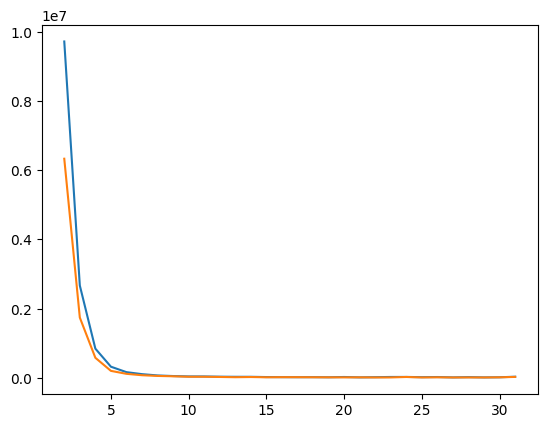

In [77]:
plt.plot(max_length,prob11)
plt.plot(max_length,prob22)

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

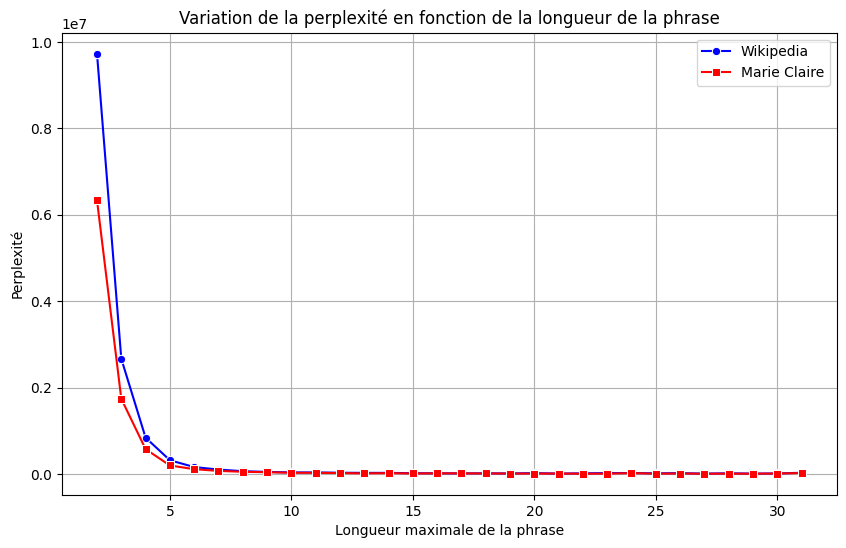

In [79]:
plt.figure(figsize=(10, 6))

# Tracé des deux courbes
sns.lineplot(x=max_length, y=prob1, label="Wikipedia", marker="o", color="blue")
sns.lineplot(x=max_length, y=prob2, label="Marie Claire", marker="s", color="red")

# Personnalisation
plt.xlabel("Longueur maximale de la phrase")
plt.ylabel("Perplexité")
plt.title("Variation de la perplexité en fonction de la longueur de la phrase")
plt.legend()
plt.grid(True)

# Affichage
plt.show()

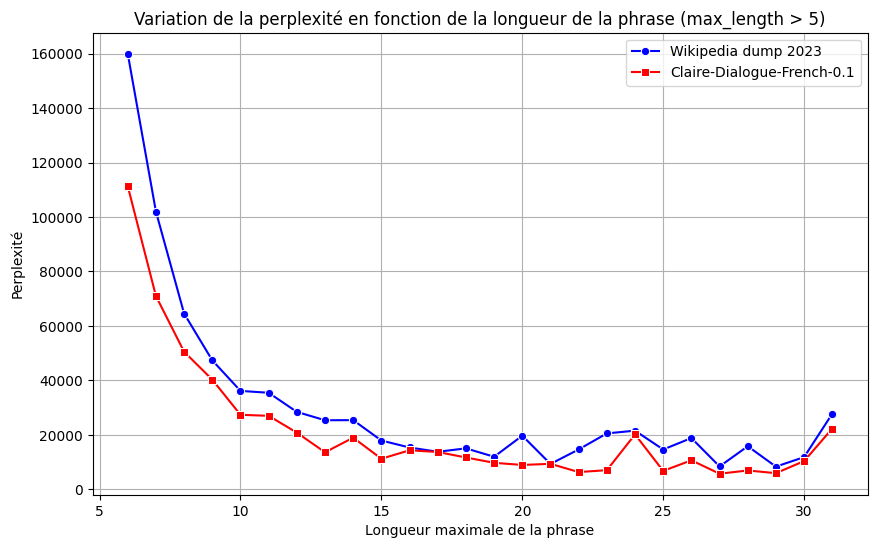

In [81]:
filtered_indices = [i for i, x in enumerate(max_length) if x > 5]
max_length_filtered = [max_length[i] for i in filtered_indices]
prob1_filtered = [prob1[i] for i in filtered_indices]
prob2_filtered = [prob2[i] for i in filtered_indices]

# Création du tracé
plt.figure(figsize=(10, 6))

# Tracé des courbes filtrées
sns.lineplot(x=max_length_filtered, y=prob1_filtered, label="Wikipedia dump 2023", marker="o", color="blue")
sns.lineplot(x=max_length_filtered, y=prob2_filtered, label="Claire-Dialogue-French-0.1", marker="s", color="red")

# Personnalisation
plt.xlabel("Longueur maximale de la phrase")
plt.ylabel("Perplexité")
plt.title("Variation de la perplexité en fonction de la longueur de la phrase (max_length > 5)")
plt.legend()
plt.grid(True)

# Affichage
plt.show()